# TP 02 — Classification de Pièces de Monnaie

# 1. Imports

In [1]:
import os, time, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

 Device: cuda
   GPU: Tesla T4


## 2. Dataset

In [2]:
import gdown
import zipfile

FILE_ID    = '1e5jOTaVKqeAoHLi_UaOI1OrDievEDUHq'
OUTPUT_ZIP = 'coin_data.zip'
DATA_DIR   = 'coin_dataset'

if not os.path.exists(OUTPUT_ZIP):
    print('Téléchargement...')
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', OUTPUT_ZIP, quiet=False)

if not os.path.exists(DATA_DIR):
    print('Extraction...')
    with zipfile.ZipFile(OUTPUT_ZIP, 'r') as zf:
        zf.extractall(DATA_DIR)

# Afficher la structure complète
print('\nStructure extraite:')
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    if level > 3: continue
    print('  '*level + os.path.basename(root) + '/')
    if level <= 2:
        for f in sorted(files)[:5]:
            print('  '*(level+1) + f)
        if len(files) > 5:
            print('  '*(level+1) + f'... ({len(files)} fichiers total)')

Téléchargement...


Downloading...
From (original): https://drive.google.com/uc?id=1e5jOTaVKqeAoHLi_UaOI1OrDievEDUHq
From (redirected): https://drive.google.com/uc?id=1e5jOTaVKqeAoHLi_UaOI1OrDievEDUHq&confirm=t&uuid=87e82f12-39dd-466c-b88d-d0288705b734
To: /content/coin_data.zip
100%|██████████| 872M/872M [00:05<00:00, 155MB/s]


Extraction...

Structure extraite:
coin_dataset/
  kaggle/
    sample_submission.csv
    test.csv
    train.csv
    test/
      10020.jpg
      10021.jpg
      10022.jpg
      10042.jpg
      10043.jpg
      ... (1283 fichiers total)
    train/
      1.jpg
      10.jpg
      100.jpg
      1000.jpg
      10000.jpg
      ... (10368 fichiers total)


## 3. Chargement du Dataset

In [3]:
DATA_DIR  = 'coin_dataset/kaggle'
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')  # colonnes: Id, Class
TEST_CSV  = os.path.join(DATA_DIR, 'test.csv')   # colonnes: Id

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f'Train shape: {train_df.shape}')
print(f'Test shape : {test_df.shape}')
print()
print('Exemple train:')
print(train_df.head())
print()
print('Exemple test:')
print(test_df.head())

Train shape: (10368, 2)
Test shape : (1282, 1)

Exemple train:
   Id                               Class
0   1  1 Cent,Australian dollar,australia
1   2  1 Cent,Australian dollar,australia
2   3  1 Cent,Australian dollar,australia
3   4  1 Cent,Australian dollar,australia
4   5  1 Cent,Australian dollar,australia

Exemple test:
   Id
0  33
1  34
2  35
3  36
4  69


In [4]:

TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
TEST_CSV  = os.path.join(DATA_DIR, 'test.csv')

def get_img_path(img_id, split='train'):
    for ext in ['.jpg', '.jpeg', '.png']:
        p = os.path.join(DATA_DIR, split, str(img_id) + ext)
        if os.path.exists(p):
            return p
    return None

train_df['path'] = train_df['Id'].apply(lambda x: get_img_path(x, 'train'))
test_df['path']  = test_df['Id'].apply(lambda x: get_img_path(x, 'test'))

missing_train = train_df['path'].isna().sum()
missing_test  = test_df['path'].isna().sum()
print(f'Train : {len(train_df) - missing_train}/{len(train_df)} images trouvées')
print(f'Test  : {len(test_df)  - missing_test}/{len(test_df)}   images trouvées')

train_df = train_df.dropna(subset=['path']).reset_index(drop=True)

# ── Encoder les labels ──
unique_classes = sorted(train_df['Class'].unique())
NUM_CLASSES    = len(unique_classes)
class2idx      = {c: i for i, c in enumerate(unique_classes)}
idx2class      = {i: c for c, i in class2idx.items()}

train_df['label_idx'] = train_df['Class'].map(class2idx)

print(f'\nNombre de classes : {NUM_CLASSES}')
print(f'Exemples de classes:')
for c in unique_classes[:5]:
    print(f'  "{c}"')

Train : 10358/10368 images trouvées
Test  : 1282/1282   images trouvées

Nombre de classes : 315
Exemples de classes:
  "1 2 Dollar,US Dollar,usa"
  "1 2 Dollar,taiwan Dollar,taiwan"
  "1 2 Franc,Swiss Franc,switzerland"
  "1 2 New Sheqel,Israeli New Shekel,israel"
  "1 4 Dollar,US Dollar,usa"


## 4. Exploration du Dataset

Total images train : 10358
Total images test  : 1282
Nombre de classes  : 315
Min/Max/Moy images : 13 / 108 / 32.9
Ratio déséquilibre : 8.3x


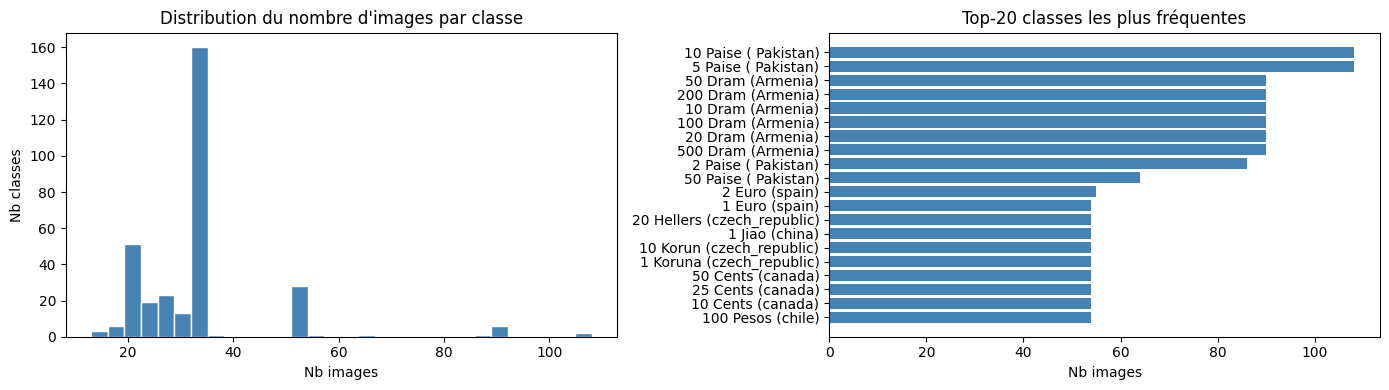

In [5]:
class_counts = train_df['Class'].value_counts()
counts = class_counts.values

print(f'Total images train : {len(train_df)}')
print(f'Total images test  : {len(test_df)}')
print(f'Nombre de classes  : {NUM_CLASSES}')
print(f'Min/Max/Moy images : {counts.min()} / {counts.max()} / {counts.mean():.1f}')
print(f'Ratio déséquilibre : {counts.max()/counts.min():.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(counts, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du nombre d\'images par classe')
axes[0].set_xlabel('Nb images'); axes[0].set_ylabel('Nb classes')

top20 = class_counts.head(20)
labels_short = [c.split(',')[0] + ' (' + c.split(',')[-1] + ')' for c in top20.index]
axes[1].barh(labels_short[::-1], top20.values[::-1], color='steelblue')
axes[1].set_title('Top-20 classes les plus fréquentes')
axes[1].set_xlabel('Nb images')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

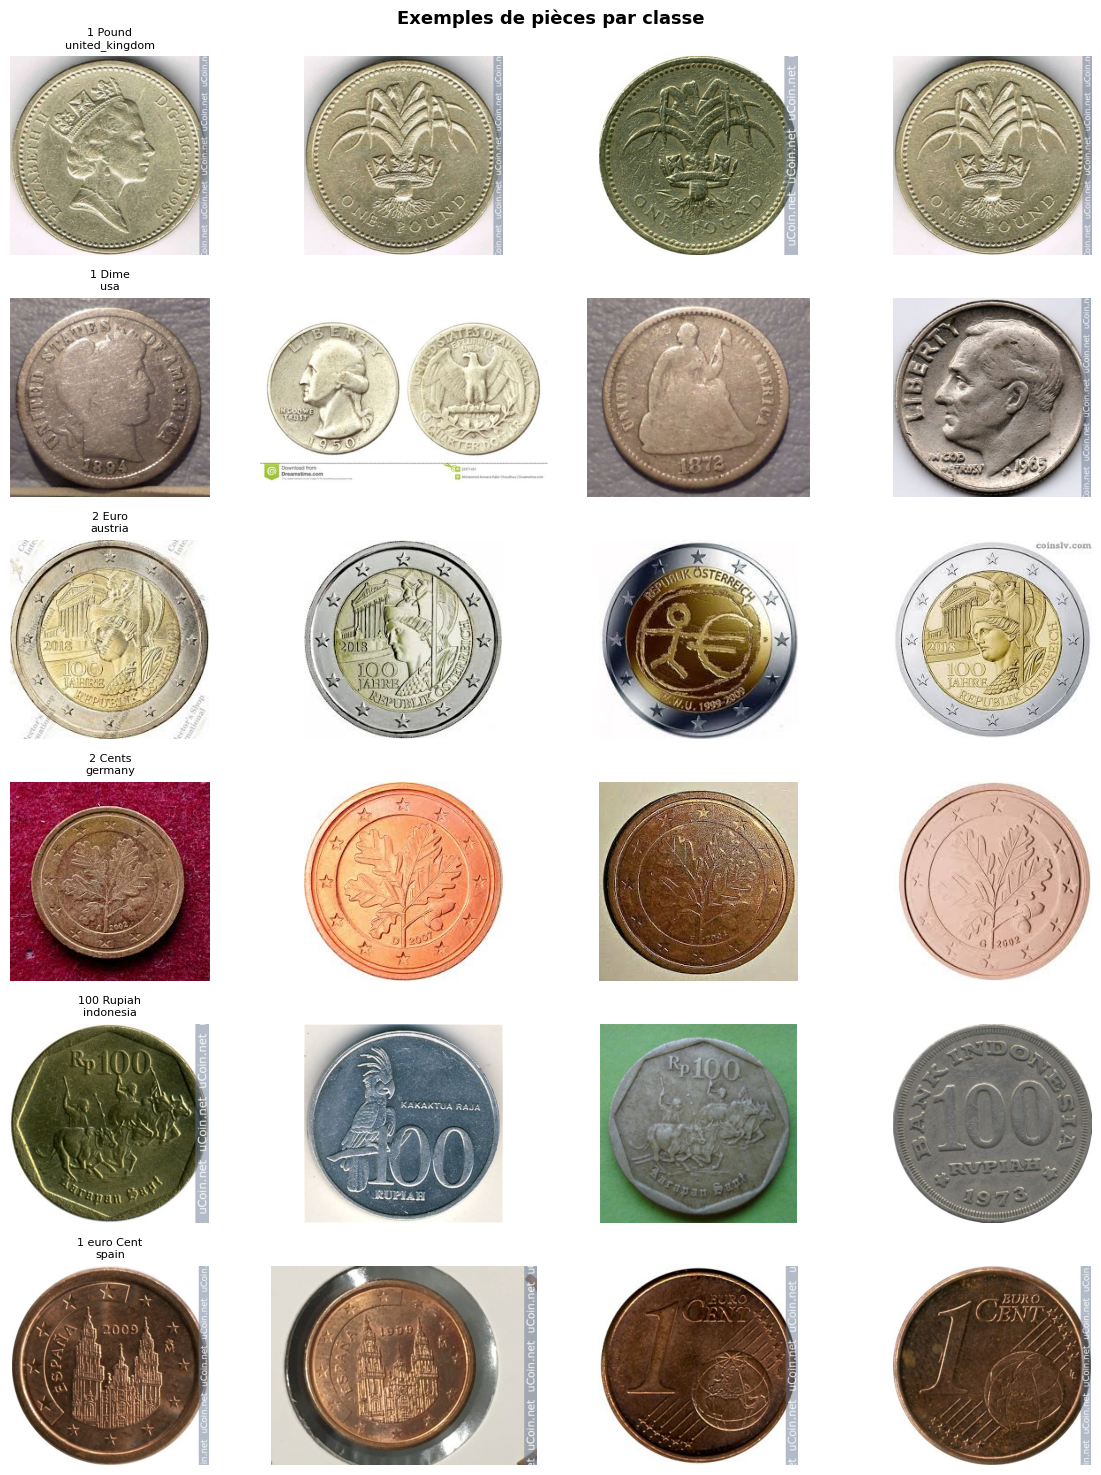

In [6]:
# Visualiser quelques pièces
n_classes_show = 6
sample_classes = random.sample(unique_classes, n_classes_show)

fig, axes = plt.subplots(n_classes_show, 4, figsize=(12, n_classes_show * 2.5))
for i, cls in enumerate(sample_classes):
    paths = train_df[train_df['Class'] == cls]['path'].tolist()
    sample_paths = random.sample(paths, min(4, len(paths)))
    for j, p in enumerate(sample_paths):
        img = Image.open(p).convert('RGB')
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            parts = cls.split(',')
            title = f'{parts[0]}\n{parts[-1].strip()}'
            axes[i, j].set_title(title, fontsize=8)

plt.suptitle('Exemples de pièces par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. PyTorch & DataLoaders

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
BATCH_SIZE    = 64
VAL_SPLIT     = 0.15

# Augmentations spécifiques aux pièces
# → RandomRotation(180) car les pièces sont circulaires (invariance rotationnelle)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),             # AlexNet paper : crops 224x224
    transforms.RandomHorizontalFlip(),       # AlexNet paper : horizontal flips
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),          # Spécifique pièces
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# lit les images à partir d'un DataFrame
class CoinDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label


# Split stratifié train / val
df_train, df_val = train_test_split(
    train_df,
    test_size=VAL_SPLIT,
    stratify=train_df['label_idx'],
    random_state=SEED
)

train_dataset = CoinDataset(df_train, train_transform)
val_dataset   = CoinDataset(df_val,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'   Dataset prêt')
print(f'   Classes    : {NUM_CLASSES}')
print(f'   Train      : {len(train_dataset)} images')
print(f'   Validation : {len(val_dataset)} images')

imgs, lbls = next(iter(train_loader))
print(f'   Batch      : {imgs.shape}')

   Dataset prêt
   Classes    : 315
   Train      : 8804 images
   Validation : 1554 images
   Batch      : torch.Size([64, 3, 224, 224])


## 6. Architecture AlexNet

| Couche | Détails |
|--------|---------|
| Conv1  | 96 kernels 11×11, stride=4 → ReLU → LRN → MaxPool |
| Conv2  | 256 kernels 5×5 → ReLU → LRN → MaxPool |
| Conv3  | 384 kernels 3×3 → ReLU |
| Conv4  | 384 kernels 3×3 → ReLU |
| Conv5  | 256 kernels 3×3 → ReLU → MaxPool |
| FC6    | 4096 → ReLU → Dropout(0.5) |
| FC7    | 4096 → ReLU → Dropout(0.5) |
| FC8    | NUM_CLASSES (309) |

In [8]:
class AlexNet(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Conv1 : 96 kernels 11×11, stride=4
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv2 : 256 kernels 5×5
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3 : 384 kernels 3×3
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4 : 384 kernels 3×3
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5 : 256 kernels 3×3
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

        # Initialisation
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, mean=0, std=0.01)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.01)
                nn.init.constant_(m.bias, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model = AlexNet(num_classes=NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'  AlexNet instancié')
print(f'   Paramètres : {n_params:,}')
print(f'   Classes    : {NUM_CLASSES}')

# Vérification du forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    out   = model(dummy)
print(f'   Output     : {out.shape}  ')

  AlexNet instancié
   Paramètres : 59,571,899
   Classes    : 315
   Output     : torch.Size([2, 315])  


## 7. Entraînement

In [9]:
# ── Weighted CrossEntropyLoss (gère le déséquilibre des classes) ──────────────
label_counts_arr = np.array([
    (df_train['label_idx'] == i).sum() for i in range(NUM_CLASSES)
], dtype=float)
label_counts_arr = np.maximum(label_counts_arr, 1)  # éviter div/0
class_weights    = len(df_train) / (NUM_CLASSES * label_counts_arr)
criterion        = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(class_weights).to(device)
)

criterion = nn.CrossEntropyLoss()  # remove weighted loss for now

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.1, patience=7
)

NUM_EPOCHS = 30
print(f'Entraînement configuré : {NUM_EPOCHS} epochs, SGD lr=1e-4')

Entraînement configuré : 30 epochs, SGD lr=1e-4


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(lbls).sum().item()
        n          += lbls.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out  = model(imgs)
        loss = criterion(out, lbls)
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(lbls).sum().item()
        n          += lbls.size(0)
    return total_loss / n, correct / n


# ── Boucle d'entraînement ─────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
best_weights  = copy.deepcopy(model.state_dict())

print(f'{"Ep":>4} | {"TrLoss":>8} | {"TrAcc":>7} | {"VaLoss":>8} | {"VaAcc":>7} | LR')
print('─' * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_l, tr_a = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_l, va_a = evaluate(model, val_loader, criterion, device)
    scheduler.step(va_a)
    lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_l)
    history['train_acc'].append(tr_a)
    history['val_loss'].append(va_l)
    history['val_acc'].append(va_a)

    flag = ''
    if va_a > best_val_acc:
        best_val_acc = va_a
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, 'best_alexnet_scratch.pth')
        flag = ' ⭐'

    elapsed = time.time() - t0
    print(f'{epoch:>4} | {tr_l:>8.4f} | {tr_a*100:>6.2f}% | '
          f'{va_l:>8.4f} | {va_a*100:>6.2f}% | {lr:.0e}  [{elapsed:.0f}s]{flag}')

model.load_state_dict(best_weights)
print(f'\nMeilleure val_acc (scratch) : {best_val_acc*100:.2f}%')

  Ep |   TrLoss |   TrAcc |   VaLoss |   VaAcc | LR
──────────────────────────────────────────────────────────
   1 |   5.8588 |   1.07% |   5.5749 |   1.35% | 1e-04  [103s] ⭐
   2 |   5.5270 |   2.06% |   5.3257 |   3.28% | 1e-04  [100s] ⭐
   3 |   5.3382 |   2.89% |   5.2442 |   2.96% | 1e-04  [104s]
   4 |   5.2449 |   3.36% |   5.1731 |   5.08% | 1e-04  [101s] ⭐
   5 |   5.1728 |   4.48% |   5.0806 |   5.86% | 1e-04  [101s] ⭐
   6 |   5.0730 |   5.60% |   4.9554 |   6.95% | 1e-04  [99s] ⭐
   7 |   4.9360 |   6.59% |   4.8812 |   7.40% | 1e-04  [101s] ⭐
   8 |   4.8009 |   7.54% |   4.7084 |  10.23% | 1e-04  [101s] ⭐
   9 |   4.7089 |   8.38% |   4.5933 |   9.59% | 1e-04  [99s]
  10 |   4.6224 |   9.30% |   4.5407 |   9.91% | 1e-04  [100s]
  11 |   4.5309 |   9.76% |   4.4540 |  11.07% | 1e-04  [101s] ⭐
  12 |   4.4326 |  10.90% |   4.4453 |  11.84% | 1e-04  [100s] ⭐
  13 |   4.3689 |  11.84% |   4.3482 |  12.87% | 1e-04  [101s] ⭐
  14 |   4.3052 |  12.21% |   4.3349 |  13.32% | 1e-

## 8. learning curve

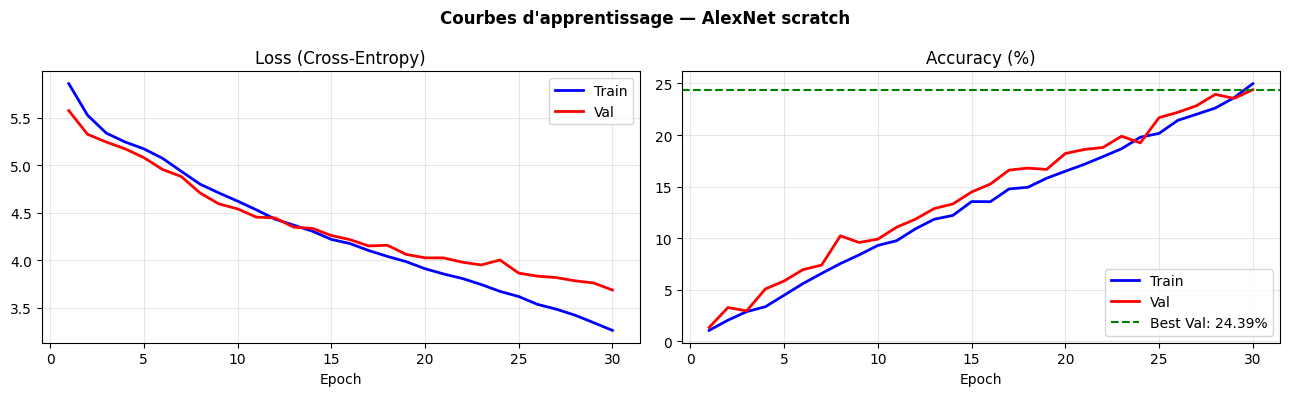

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], 'b-', lw=2, label='Train')
axes[0].plot(ep, history['val_loss'],   'r-', lw=2, label='Val')
axes[0].set_title('Loss (Cross-Entropy)'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], 'b-', lw=2, label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   'r-', lw=2, label='Val')
axes[1].axhline(best_val_acc*100, color='green', linestyle='--', lw=1.5,
                label=f'Best Val: {best_val_acc*100:.2f}%')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Courbes d\'apprentissage — AlexNet scratch', fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Évaluation quantitative

In [12]:
@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    for imgs, lbls in loader:
        out   = model(imgs.to(device))
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        y_true.extend(lbls.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


y_true, y_pred, y_prob = get_all_predictions(model, val_loader, device)

# Top-1 et Top-5
top1 = accuracy_score(y_true, y_pred)
top5 = np.mean([
    y_true[i] in np.argsort(y_prob[i])[::-1][:5]
    for i in range(len(y_true))
])

print('=' * 58)
print('  📊 RÉSULTATS — VALIDATION SET')
print('─' * 58)
print(f'  Top-1 Accuracy : {top1*100:.2f}%')
print(f'  Top-5 Accuracy : {top5*100:.2f}%')
print('=' * 58)
print('  📊 LEADERBOARD KAGGLE (référence)')
print('─' * 58)
print('  #1  Xuban Arrieta    : 90.17%')
print('  #2  Bekarys Toleshov : 90.17%')
print('  #3  Adishesh Balaji  : 89.55%')
print(f'  Nous (AlexNet scr.) : {top1*100:.2f}%')
print('=' * 58)

  📊 RÉSULTATS — VALIDATION SET
──────────────────────────────────────────────────────────
  Top-1 Accuracy : 24.39%
  Top-5 Accuracy : 45.37%
  📊 LEADERBOARD KAGGLE (référence)
──────────────────────────────────────────────────────────
  #1  Xuban Arrieta    : 90.17%
  #2  Bekarys Toleshov : 90.17%
  #3  Adishesh Balaji  : 89.55%
  Nous (AlexNet scr.) : 24.39%


Classes les plus difficiles (F1 le plus bas) :
                                   class  f1  support
  5 Rand,South African Rand,south_africa 0.0      5.0
                    1 Euro,Euro,portugal 0.0      3.0
           5 Rubles,Russian Ruble,russia 0.0      5.0
             5 Rupees,Indian Rupee,india 0.0      5.0
        5 Sen,Malaysian Ringgit,malaysia 0.0      5.0
   5 Sentimos,Philipine peso,philippines 0.0      5.0
            5 Won,Korean Won,south_korea 0.0      4.0
                  5 euro Cent,Euro,spain 0.0      5.0
     10 Cents,Singapore Dollar,singapore 0.0      5.0
10 Cents,South African Rand,south_africa 0.0      5.0


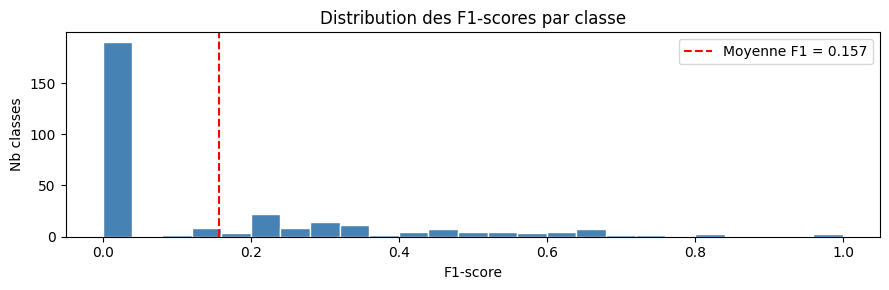

In [13]:
# Classes les plus difficiles (F1 les plus bas)
from sklearn.metrics import classification_report

class_names = [idx2class[i] for i in range(NUM_CLASSES)]
report = classification_report(y_true, y_pred, target_names=class_names,
                                output_dict=True, zero_division=0)
f1_df = pd.DataFrame({
    'class': class_names,
    'f1': [report[c]['f1-score'] for c in class_names],
    'support': [report[c]['support'] for c in class_names]
}).sort_values('f1')

print('Classes les plus difficiles (F1 le plus bas) :')
print(f1_df[f1_df['support'] > 0].head(10).to_string(index=False))

# Distribution F1
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(f1_df['f1'], bins=25, color='steelblue', edgecolor='white')
ax.axvline(f1_df['f1'].mean(), color='red', linestyle='--',
           label=f'Moyenne F1 = {f1_df["f1"].mean():.3f}')
ax.set_title('Distribution des F1-scores par classe')
ax.set_xlabel('F1-score'); ax.set_ylabel('Nb classes')
ax.legend(); plt.tight_layout(); plt.show()

## 10. AlexNet Fine-tuning (poids ImageNet)

In [14]:
# AlexNet pré-entraîné sur ImageNet
model_ft = models.alexnet(weights='IMAGENET1K_V1')
model_ft.classifier[6] = nn.Linear(4096, NUM_CLASSES)
model_ft = model_ft.to(device)

optimizer_ft = optim.SGD(
    model_ft.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4
)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=30)

NUM_EPOCHS_FT = 30
history_ft    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_ft   = 0.0
best_wts_ft   = copy.deepcopy(model_ft.state_dict())

print(f'Fine-tuning — {NUM_EPOCHS_FT} epochs, lr=1e-3, CosineAnnealing')
print(f'{"Ep":>4} | {"TrAcc":>7} | {"VaAcc":>7}')
print('─' * 25)

for epoch in range(1, NUM_EPOCHS_FT + 1):
    tr_l, tr_a = train_one_epoch(model_ft, train_loader, criterion, optimizer_ft, device)
    va_l, va_a = evaluate(model_ft, val_loader, criterion, device)
    scheduler_ft.step()

    history_ft['train_loss'].append(tr_l)
    history_ft['train_acc'].append(tr_a)
    history_ft['val_loss'].append(va_l)
    history_ft['val_acc'].append(va_a)

    flag = ''
    if va_a > best_val_ft:
        best_val_ft = va_a
        best_wts_ft = copy.deepcopy(model_ft.state_dict())
        torch.save(best_wts_ft, 'best_alexnet_finetune.pth')
        flag = ' ⭐'

    print(f'{epoch:>4} | {tr_a*100:>6.2f}% | {va_a*100:>6.2f}%{flag}')

model_ft.load_state_dict(best_wts_ft)
print(f'\n Meilleure val_acc (fine-tuned) : {best_val_ft*100:.2f}%')

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 96.9MB/s]


🚀 Fine-tuning — 30 epochs, lr=1e-3, CosineAnnealing
  Ep |   TrAcc |   VaAcc
─────────────────────────
   1 |   9.97% |  21.24% ⭐
   2 |  29.00% |  39.06% ⭐
   3 |  42.82% |  48.20% ⭐
   4 |  51.95% |  53.22% ⭐
   5 |  58.51% |  56.76% ⭐
   6 |  64.05% |  63.06% ⭐
   7 |  68.36% |  62.29%
   8 |  71.19% |  64.35% ⭐
   9 |  74.92% |  65.44% ⭐
  10 |  77.95% |  67.31% ⭐
  11 |  80.16% |  69.69% ⭐
  12 |  81.14% |  70.01% ⭐
  13 |  83.69% |  70.72% ⭐
  14 |  84.76% |  70.27%
  15 |  86.28% |  70.21%
  16 |  87.71% |  71.62% ⭐
  17 |  88.72% |  72.01% ⭐
  18 |  90.22% |  72.52% ⭐
  19 |  90.55% |  71.24%
  20 |  91.37% |  72.97% ⭐
  21 |  92.12% |  73.62% ⭐
  22 |  92.75% |  74.58% ⭐
  23 |  93.45% |  74.58%
  24 |  93.53% |  74.52%
  25 |  94.31% |  74.13%
  26 |  94.37% |  74.39%
  27 |  94.68% |  74.84% ⭐
  28 |  94.90% |  74.90% ⭐
  29 |  94.66% |  74.97% ⭐
  30 |  94.96% |  74.97%

 Meilleure val_acc (fine-tuned) : 74.97%


  📊 COMPARAISON DES APPROCHES
──────────────────────────────────────────────────────────
  AlexNet scratch      Top-1: 24.39%   Top-5: 45.37%
  AlexNet fine-tuned   Top-1: 74.97%   Top-5: 88.48%
  Kaggle #1                   90.17%


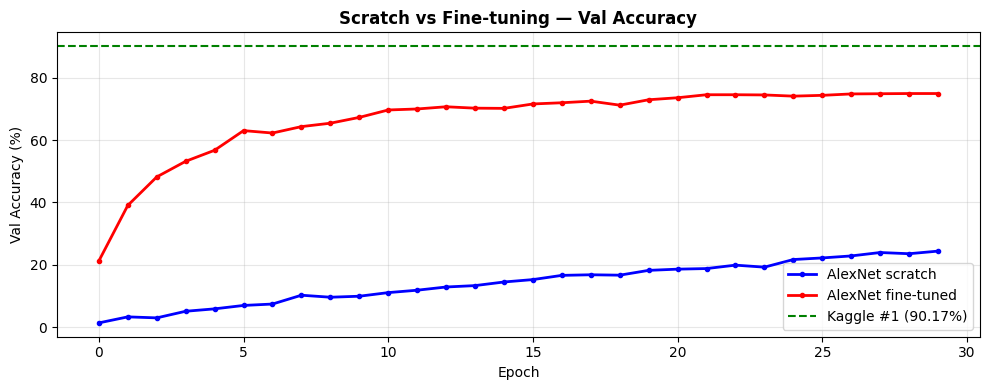

In [15]:
# Résultats fine-tuned
y_true_ft, y_pred_ft, y_prob_ft = get_all_predictions(model_ft, val_loader, device)
top1_ft = accuracy_score(y_true_ft, y_pred_ft)
top5_ft = np.mean([
    y_true_ft[i] in np.argsort(y_prob_ft[i])[::-1][:5]
    for i in range(len(y_true_ft))
])

print('=' * 58)
print('  📊 COMPARAISON DES APPROCHES')
print('─' * 58)
print(f'  AlexNet scratch      Top-1: {top1*100:.2f}%   Top-5: {top5*100:.2f}%')
print(f'  AlexNet fine-tuned   Top-1: {top1_ft*100:.2f}%   Top-5: {top5_ft*100:.2f}%')
print(f'  Kaggle #1                   90.17%')
print('=' * 58)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([a*100 for a in history['val_acc']],    'b-o', ms=3, lw=2, label='AlexNet scratch')
ax.plot([a*100 for a in history_ft['val_acc']], 'r-o', ms=3, lw=2, label='AlexNet fine-tuned')
ax.axhline(90.17, color='green', linestyle='--', lw=1.5, label='Kaggle #1 (90.17%)')
ax.set_title('Scratch vs Fine-tuning — Val Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. kaggle submissions

In [19]:
best_model_name = 'fine-tuned'
print(f'Modèle utilisé : AlexNet {best_model_name}')


class TestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(row['Id'])


test_dataset = TestDataset(test_df, val_transform)
test_loader  = DataLoader(test_dataset, batch_size=64,
                          shuffle=False, num_workers=2)

best_model.eval()
all_ids, all_preds = [], []

with torch.no_grad():
    for imgs, ids in test_loader:
        out   = best_model(imgs.to(device))
        preds = out.argmax(1).cpu().numpy()
        all_ids.extend(ids.numpy())
        all_preds.extend([idx2class[p] for p in preds])

submission = pd.DataFrame({'Id': all_ids, 'Class': all_preds})
submission.to_csv('submission.csv', index=False)

print(f' submission.csv créé ({len(submission)} lignes)')
print(submission.head(10).to_string())

Modèle utilisé : AlexNet fine-tuned
 submission.csv créé (1282 lignes)
    Id                                 Class
0   33    1 Cent,Australian dollar,australia
1   34    1 Cent,Australian dollar,australia
2   35    1 Cent,Australian dollar,australia
3   36    1 Cent,Australian dollar,australia
4   69  1 Penny,British Pound,united_kingdom
5   70   2 Cents,Australian dollar,australia
6   71   2 Cents,Australian dollar,australia
7   72   2 Cents,Australian dollar,australia
8  103   5 Cents,Australian dollar,australia
9  104   5 Cents,Australian dollar,australia
